In [33]:
import joblib
import pandas as pd

In [34]:
bundle = joblib.load(r'D:\home loan credit risk\artifact\model\model.pkl')
model = bundle['model']
features = bundle['features']

In [35]:
df = pd.read_csv(r'D:\home loan credit risk\artifact\scorecard\scored_train.csv')

In [36]:
scorecard = pd.read_csv(r'D:\home loan credit risk\artifact\scorecard\scorecard_table.csv')

In [37]:
df.head(3)

,CODE_GENDER,AMT_CREDIT,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,REGION_RATING_CLIENT_W_CITY,EXT_SOURCE_1,EXT_SOURCE_3,FLAG_DOCUMENT_3,...,IP_NUM_COMPLETED_LOANS,PA_AVG_AMT_ANNUITY_POS,PA_RATIO_CREDIT_APPLICATION_POS,PA_RATIO_CREDIT_APPLICATION_Cash,PA_RATIO_APPROVED_LOANS,PA_AVG_RISK_WEIGHT_1080D,CB_WT_CREDIT_UTIL_TREND_3M_12M,CB_AVG_ATM_WITHDRAWAL_FREQ_6M,credit_score,TARGET
0,F,227520.0,180000.0,Commercial associate,Higher education,Married,2,0.384582,0.622922,1,...,5.0,4726.665,0.958164,1.136703,1.0,3.0,-0.06457,0.0,729.32,0
1,M,161730.0,135000.0,Commercial associate,NaN,Married,3,NaN,NaN,1,...,4.0,9049.151,1.024944,1.132000,0.8,2.8,-99999.00000,-99999.0,705.37,0
2,M,728847.0,553500.0,Working,NaN,Single,2,NaN,0.598926,1,...,1.0,12991.005,0.929718,-99999.000000,1.0,-99999.0,-99999.00000,-99999.0,723.40,1


In [38]:
scorecard

,score_decile,count,bad_count,pd_model_avg,raw_pd_avg,min_score,max_score,good_count,pd_model_pct,raw_pd_pct,observed_dr_pct,bad_capture_rate_cumsum,lift
0,"(614.719, 690.96]",24605,6410,0.266568,0.789002,614.72,690.96,18195,26.66,78.90,26.05,32.28,3.3020
1,"(690.96, 705.14]",24622,3780,0.149843,0.656147,690.97,705.14,20842,14.98,65.61,15.35,51.31,1.8561
2,"(705.14, 715.77]",24584,2673,0.104869,0.560536,705.15,715.77,21911,10.49,56.05,10.87,64.77,1.2990
3,"(715.77, 724.64]",24601,1951,0.078084,0.480278,715.78,724.64,22650,7.81,48.03,7.93,74.59,0.9672
4,"(724.64, 732.72]",24622,1504,0.060049,0.411007,724.65,732.72,23118,6.00,41.10,6.11,82.17,0.7438
5,"(732.72, 740.49]",24572,1141,0.046826,0.349680,732.73,740.49,23431,4.68,34.97,4.64,87.91,0.5800
6,"(740.49, 748.36]",24611,900,0.037040,0.296535,740.50,748.36,23711,3.70,29.65,3.66,92.44,0.4588
7,"(748.36, 756.96]",24601,667,0.028670,0.244439,748.37,756.96,23934,2.87,24.44,2.71,95.80,0.3551
8,"(756.96, 767.9]",24596,478,0.021513,0.194202,756.97,767.90,24118,2.15,19.42,1.94,98.21,0.2665
9,"(767.9, 817.89]",24594,356,0.013720,0.131837,767.91,817.89,24238,1.37,13.18,1.45,100.00,0.1699


In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

In [40]:
l1 = [1,2,3,4,5,5,6,7,88,9,9,0,1,23,123,123,123,23,4,5,67,8,8]
import numpy as np
np.histogram(l1,bins=10)[1]


array([  0. ,  12.3,  24.6,  36.9,  49.2,  61.5,  73.8,  86.1,  98.4,
       110.7, 123. ])

<Axes: xlabel='credit_score', ylabel='Count'>

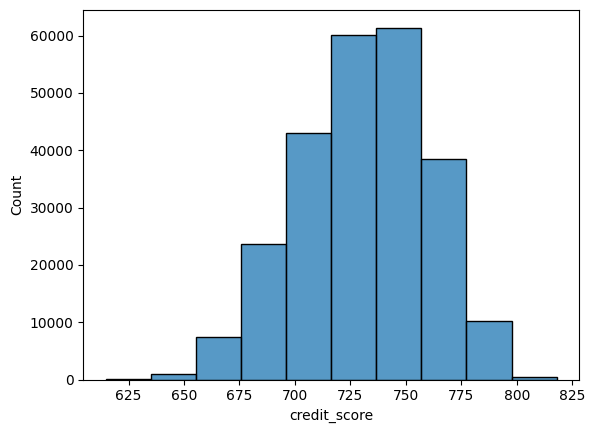

In [41]:
sns.histplot(df['credit_score'],bins=10)

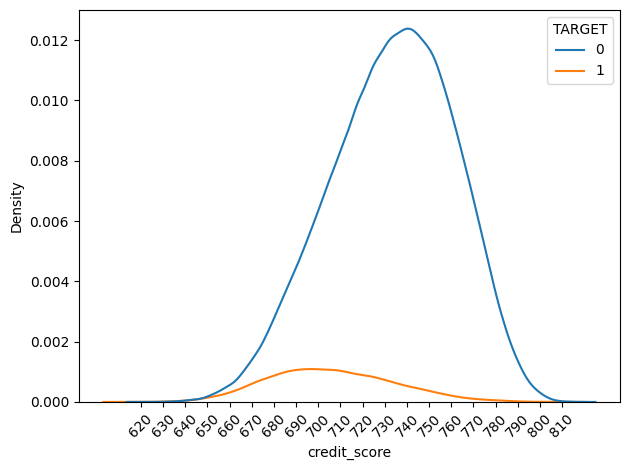

In [42]:

sns.kdeplot(data=df, x='credit_score', hue='TARGET')

plt.xticks(range(620, 820, 10))  # every 10 points
plt.xticks(rotation=45)           # rotate so they don't overlap
plt.tight_layout()
plt.show()

In [49]:
bad_loss   = 0.70   # lgd assumption rate
good_gain  = 0.06  # net margin assumption

# For each decile calculate expected value
scorecard['expected_value'] = (
    (1 - scorecard['pd_model_avg']) * good_gain -
    scorecard['pd_model_avg'] * bad_loss
)

scorecard[['score_decile', 'pd_model_avg', 'expected_value']]

,score_decile,pd_model_avg,expected_value
0,"(614.719, 690.96]",0.266568,-0.142592
1,"(690.96, 705.14]",0.149843,-0.053881
2,"(705.14, 715.77]",0.104869,-0.019700
3,"(715.77, 724.64]",0.078084,0.000656
4,"(724.64, 732.72]",0.060049,0.014362
5,"(732.72, 740.49]",0.046826,0.024412
6,"(740.49, 748.36]",0.037040,0.031849
7,"(748.36, 756.96]",0.028670,0.038211
8,"(756.96, 767.9]",0.021513,0.043650
9,"(767.9, 817.89]",0.013720,0.049573


* approve_score cut off : 724<br>
* I set the cutoff above the breakeven point to stay profitable even if default rates rise during a bad economy

In [44]:
from scipy.stats import ks_2samp

good_scores = df[df['TARGET']==0]['credit_score']
bad_scores  = df[df['TARGET']==1]['credit_score']

ks_stat, _ = ks_2samp(good_scores, bad_scores)
print(f"KS Statistic: {ks_stat:.4f}")

KS Statistic: 0.3815
